In [7]:
import torch, os, sys, platform
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU is OFF. Enable Kaggle GPU before training.")

Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2) Inspect attached Kaggle inputs

In [9]:
from pathlib import Path
INPUT = Path("/kaggle/input")
print("Attached datasets:")
for p in INPUT.iterdir():
    print(" -", p)

Attached datasets:
 - /kaggle/input/datasets


## 3) Find / extract BadODD

Attach your BadODD Kaggle dataset first. This cell automatically finds a ZIP and extracts it to `/kaggle/working/badodd_raw`.

In [10]:
from pathlib import Path
import zipfile, os, shutil

WORK = Path("/kaggle/working")
RAW = WORK / "badodd_raw"

# Find candidate zip(s)
zips = list(INPUT.rglob("*.zip"))
print("ZIP files found:", len(zips))
for z in zips[:10]:
    print(" -", z)

if zips:
    # Prefer a zip with badodd in its name
    badodd_zips = [z for z in zips if "badodd" in z.name.lower()]
    zip_path = badodd_zips[0] if badodd_zips else zips[0]
    print("\\nUsing:", zip_path)
    RAW.mkdir(parents=True, exist_ok=True)
    marker = RAW / ".extracted_ok"
    if not marker.exists():
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(RAW)
        marker.write_text("ok")
        print("Extraction complete.")
    else:
        print("Already extracted in this session.")
else:
    # If Kaggle already unpacked the dataset, use the input tree directly.
    RAW = INPUT
    print("No ZIP found; using /kaggle/input directly.")

ZIP files found: 0
No ZIP found; using /kaggle/input directly.


## 4) Read BadODD class names

In [11]:
# Find the official .names file
name_files = list(INPUT.rglob("*.names")) + list(Path("/kaggle/working").rglob("*.names"))
print("Names files:", name_files)

if name_files:
    names_path = name_files[0]
    class_names = [x.strip() for x in names_path.read_text(errors="ignore").splitlines() if x.strip()]
    print("Using official class names from:", names_path)
else:
    # Fallback based on the published BadODD class list.
    # Prefer the official banglatesla.names whenever available.
    class_names = [
        "auto-rickshaw",
        "bicycle",
        "bus",
        "car",
        "cart-vehicle",
        "construction-vehicle",
        "motorbike",
        "person",
        "priority-vehicle",
        "three-wheeler",
        "train",
        "truck",
        "wheelchair",
    ]
    print("WARNING: banglatesla.names was not found.")
    print("Using fallback class order. Upload/attach the official names file if possible.")

print("\\nClasses:", len(class_names))
for i, n in enumerate(class_names):
    print(i, n)

Names files: []
Using fallback class order. Upload/attach the official names file if possible.
\nClasses: 13
0 auto-rickshaw
1 bicycle
2 bus
3 car
4 cart-vehicle
5 construction-vehicle
6 motorbike
7 person
8 priority-vehicle
9 three-wheeler
10 train
11 truck
12 wheelchair


## 5) Discover images and YOLO label files

In [12]:
from collections import defaultdict

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
all_files_root = RAW

images = [p for p in all_files_root.rglob("*") if p.is_file() and p.suffix.lower() in image_exts]

txts = [
    p for p in all_files_root.rglob("*.txt")
    if p.name.lower() not in {"train.txt","val.txt","valid.txt","test.txt"}
]

label_by_stem = defaultdict(list)
for p in txts:
    # ignore obvious metadata
    if "readme" in p.name.lower():
        continue
    label_by_stem[p.stem].append(p)

pairs = []
missing = []
for img in images:
    candidates = label_by_stem.get(img.stem, [])
    if candidates:
        # prefer a txt file that looks like a label (first nonempty line starts with integer)
        chosen = None
        for c in candidates:
            try:
                lines = [ln.strip() for ln in c.read_text(errors="ignore").splitlines() if ln.strip()]
                if not lines:
                    continue
                first = lines[0].split()
                int(float(first[0]))
                if len(first) >= 5:
                    chosen = c
                    break
            except:
                pass
        if chosen is not None:
            pairs.append((img, chosen))
        else:
            missing.append(img)
    else:
        missing.append(img)

print("Images found:", len(images))
print("Image-label pairs:", len(pairs))
print("Images without detected YOLO label:", len(missing))

print("\\nFirst 5 pairs:")
for a,b in pairs[:5]:
    print(a, " <-> ", b)

if len(pairs) < 100:
    raise RuntimeError("Too few image-label pairs found. Stop here and send this output/screenshot before training.")

Images found: 10038
Image-label pairs: 10032
Images without detected YOLO label: 6
\nFirst 5 pairs:
/kaggle/input/datasets/masrafi2221949042/badodd-official/val/images/sherpur2_1073.jpg  <->  /kaggle/input/datasets/masrafi2221949042/badodd-official/val/labels/sherpur2_1073.txt
/kaggle/input/datasets/masrafi2221949042/badodd-official/val/images/mymensingh1_0.jpg  <->  /kaggle/input/datasets/masrafi2221949042/badodd-official/val/labels/mymensingh1_0.txt
/kaggle/input/datasets/masrafi2221949042/badodd-official/val/images/mymensingh1_96860.jpg  <->  /kaggle/input/datasets/masrafi2221949042/badodd-official/val/labels/mymensingh1_96860.txt
/kaggle/input/datasets/masrafi2221949042/badodd-official/val/images/khulna4_22590.jpg  <->  /kaggle/input/datasets/masrafi2221949042/badodd-official/val/labels/khulna4_22590.txt
/kaggle/input/datasets/masrafi2221949042/badodd-official/val/images/mymensingh1_106713.jpg  <->  /kaggle/input/datasets/masrafi2221949042/badodd-official/val/labels/mymensingh1_106

## 6) Verify YOLO label format

A YOLO detection row must be:

`class_id  x_center  y_center  width  height`

with coordinates normalized to 0–1.

In [13]:
bad_rows = []
max_class = -1
checked_rows = 0

for _, lab in pairs[:2000]:
    try:
        for line in lab.read_text(errors="ignore").splitlines():
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                bad_rows.append((lab, line, "fewer than 5 columns"))
                continue
            cls = int(float(parts[0]))
            vals = list(map(float, parts[1:5]))
            max_class = max(max_class, cls)
            checked_rows += 1
            if any(v < 0 or v > 1 for v in vals):
                bad_rows.append((lab, line, "coordinate outside [0,1]"))
    except Exception as e:
        bad_rows.append((lab, "", str(e)))

print("Checked rows:", checked_rows)
print("Maximum class ID seen:", max_class)
print("Bad rows:", len(bad_rows))
if bad_rows[:5]:
    print("\\nExamples:")
    for x in bad_rows[:5]:
        print(x)

if max_class >= len(class_names):
    raise RuntimeError(
        f"Found class id {max_class}, but only {len(class_names)} names. "
        "Class mapping must be fixed before training."
    )

Checked rows: 16038
Maximum class ID seen: 12
Bad rows: 0


## 7) Preserve existing split if present; otherwise create emergency 60/20/20 split

The official BadODD work uses train/validation/test splits.  
If split folder names are detectable, this notebook preserves them. Otherwise it makes a fixed random 60/20/20 split for today's baseline.

> For a final research paper, prefer an official/scene-wise split to reduce video-frame leakage.

In [14]:
import random

def split_from_path(p):
    parts = [x.lower() for x in p.parts]
    if any(x in {"train","training"} for x in parts):
        return "train"
    if any(x in {"val","valid","validation"} for x in parts):
        return "val"
    if any(x in {"test","testing"} for x in parts):
        return "test"
    return None

detected = {"train": [], "val": [], "test": []}
unknown = []

for img, lab in pairs:
    s = split_from_path(img)
    if s is None:
        s = split_from_path(lab)
    if s:
        detected[s].append((img, lab))
    else:
        unknown.append((img, lab))

print("Detected split sizes:", {k: len(v) for k,v in detected.items()})
print("Unknown split:", len(unknown))

if len(detected["train"]) >= 500 and len(detected["val"]) >= 100:
    splits = detected
    # If some pairs are unknown, add them to training rather than discard.
    splits["train"].extend(unknown)
    print("Using detected dataset splits.")
else:
    all_pairs = pairs.copy()
    random.Random(42).shuffle(all_pairs)
    n = len(all_pairs)
    n_train = int(0.60*n)
    n_val = int(0.20*n)
    splits = {
        "train": all_pairs[:n_train],
        "val": all_pairs[n_train:n_train+n_val],
        "test": all_pairs[n_train+n_val:]
    }
    print("Using emergency fixed random 60/20/20 split.")

print("Final split sizes:", {k: len(v) for k,v in splits.items()})

Detected split sizes: {'train': 5967, 'val': 2032, 'test': 2033}
Unknown split: 0
Using detected dataset splits.
Final split sizes: {'train': 5967, 'val': 2032, 'test': 2033}


## 8) Build Ultralytics-compatible directory using symlinks (no 4.4 GB copy)

In [15]:
import os, shutil
from pathlib import Path

DATASET = WORK / "badodd_yolo"

if DATASET.exists():
    shutil.rmtree(DATASET)

for split in ["train","val","test"]:
    (DATASET / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET / "labels" / split).mkdir(parents=True, exist_ok=True)

def safe_link(src, dst):
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    os.symlink(src, dst)

for split, items in splits.items():
    seen = set()
    for idx, (img, lab) in enumerate(items):
        # avoid duplicate stems by adding a short suffix when necessary
        stem = img.stem
        key = stem.lower()
        if key in seen:
            stem = f"{stem}_{idx}"
        seen.add(stem.lower())
        img_dst = DATASET / "images" / split / f"{stem}{img.suffix.lower()}"
        lab_dst = DATASET / "labels" / split / f"{stem}.txt"
        safe_link(img, img_dst)
        safe_link(lab, lab_dst)

print("Prepared:", DATASET)
for split in ["train","val","test"]:
    print(split,
          len(list((DATASET/"images"/split).iterdir())),
          len(list((DATASET/"labels"/split).iterdir())))

Prepared: /kaggle/working/badodd_yolo
train 5967 5967
val 2032 2032
test 2033 2033


## 9) Create `badodd.yaml`

In [16]:
import yaml

yaml_data = {
    "path": str(DATASET),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i:n for i,n in enumerate(class_names)}
}

YAML_PATH = WORK / "badodd.yaml"
with open(YAML_PATH, "w") as f:
    yaml.safe_dump(yaml_data, f, sort_keys=False)

print(YAML_PATH.read_text())

path: /kaggle/working/badodd_yolo
train: images/train
val: images/val
test: images/test
names:
  0: auto-rickshaw
  1: bicycle
  2: bus
  3: car
  4: cart-vehicle
  5: construction-vehicle
  6: motorbike
  7: person
  8: priority-vehicle
  9: three-wheeler
  10: train
  11: truck
  12: wheelchair



## 10) Visual sanity check — draw ground-truth boxes

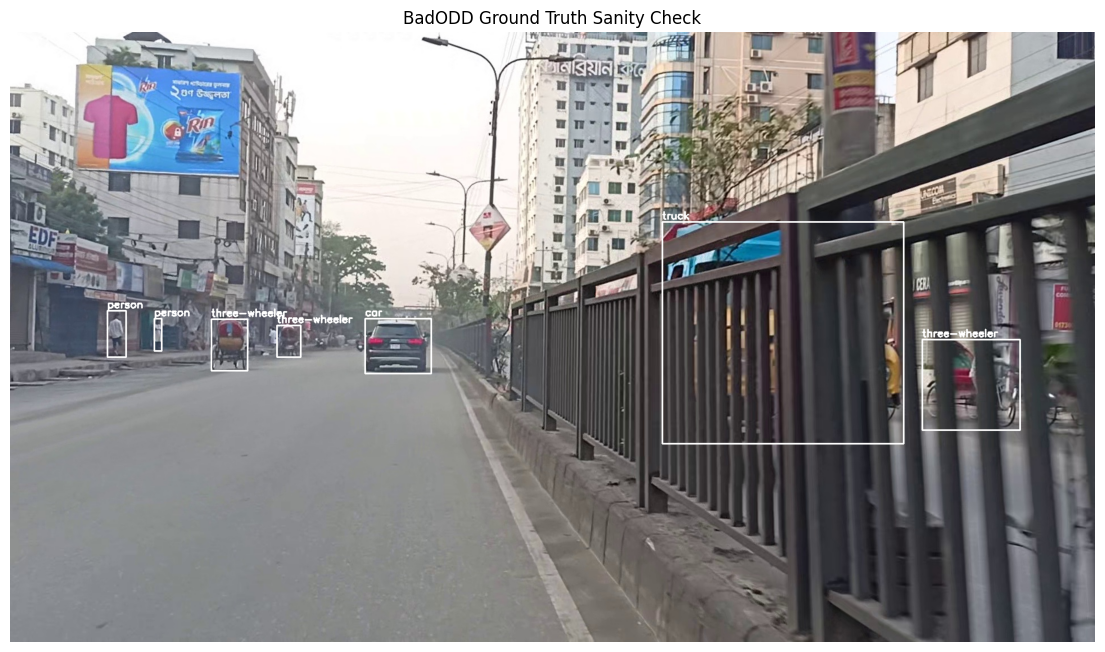

In [17]:
import cv2, matplotlib.pyplot as plt, random, numpy as np

sample_img, sample_lab = random.choice(splits["train"])
img = cv2.imread(str(sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

for line in sample_lab.read_text(errors="ignore").splitlines():
    p = line.split()
    if len(p) < 5:
        continue
    cls = int(float(p[0]))
    xc, yc, bw, bh = map(float, p[1:5])
    x1 = int((xc-bw/2)*w); y1 = int((yc-bh/2)*h)
    x2 = int((xc+bw/2)*w); y2 = int((yc+bh/2)*h)
    cv2.rectangle(img, (x1,y1), (x2,y2), (255,255,255), 2)
    cv2.putText(img, class_names[cls], (x1,max(20,y1-5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

plt.figure(figsize=(14,8))
plt.imshow(img)
plt.axis("off")
plt.title("BadODD Ground Truth Sanity Check")
plt.show()

# STOP FOR 30 SECONDS

Look at the image above.

- Boxes should sit on the correct objects.
- Class labels should make sense.
- If labels look wrong, **do not train** — fix class order first.

## 11) Install / load Ultralytics

In [18]:
!pip install -q -U ultralytics
from ultralytics import YOLO
import ultralytics
print("Ultralytics:", ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 4.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.129


## 12) Train the baseline

**Fast Task-3 configuration:** YOLO11n, 10 epochs, 416px.  
This is intentionally a preliminary baseline, not the final research model.

In [19]:
from ultralytics.utils import SETTINGS

SETTINGS["raytune"] = False

print("RayTune enabled:", SETTINGS["raytune"])

RayTune enabled: False


In [20]:
from ultralytics import YOLO
from pathlib import Path
import shutil

model = YOLO("yolo11n.pt")

model.train(
    data="/kaggle/working/badodd.yaml",
    epochs=10,
    imgsz=416,
    batch=32,
    device=0,
    workers=4,

    project="/kaggle/working/runs",
    name="badodd_final",
    exist_ok=True,

    save=True,
    save_period=5,
    plots=True
)

RUN = Path("/kaggle/working/runs/badodd_final")
BEST = RUN / "weights" / "best.pt"

print("\nTraining complete")
print("best.pt exists:", BEST.exists())

if BEST.exists():
    shutil.copy2(
        BEST,
        "/kaggle/working/BadODD_best.pt"
    )

    shutil.make_archive(
        "/kaggle/working/BadODD_RESULTS",
        "zip",
        RUN
    )

    print("\nFILES READY:")
    print("/kaggle/working/BadODD_best.pt")
    print("/kaggle/working/BadODD_RESULTS.zip")

Ultralytics 8.4.129 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/badodd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=badodd_final, nbs=64, nms=False, o

## 13) Validate `best.pt` and print presentation-ready metrics

In [23]:
from pathlib import Path
import pandas as pd

# ======================================
# Correct 10-epoch training run
# ======================================
RUN = Path("/kaggle/working/runs/badodd_final")
CSV = RUN / "results.csv"
BEST = RUN / "weights" / "best.pt"

print("Run folder exists :", RUN.exists())
print("best.pt exists    :", BEST.exists())
print("results.csv exists:", CSV.exists())

assert BEST.exists(), "best.pt not found!"
assert CSV.exists(), "results.csv not found!"

# ======================================
# Read metrics already produced
# during training
# ======================================
df = pd.read_csv(CSV)

# Remove accidental whitespace from column names
df.columns = df.columns.str.strip()

print("\nAvailable columns:")
print(df.columns.tolist())

# ======================================
# Select best epoch based on mAP50-95
# ======================================
best_idx = df["metrics/mAP50-95(B)"].idxmax()
best = df.loc[best_idx]

P = float(best["metrics/precision(B)"])
R = float(best["metrics/recall(B)"])
MAP50 = float(best["metrics/mAP50(B)"])
MAP5095 = float(best["metrics/mAP50-95(B)"])

F1 = 2 * P * R / (P + R + 1e-12)

# ======================================
# Presentation-ready summary
# ======================================
summary = pd.DataFrame([{
    "Best Epoch": int(best["epoch"]) + 1,
    "Precision": P,
    "Recall": R,
    "F1-score": F1,
    "mAP@50": MAP50,
    "mAP@50-95": MAP5095
}])

display(summary.round(4))

summary.to_csv(
    "/kaggle/working/task3_metrics.csv",
    index=False
)

print("\n===== PRESENTATION METRICS =====")
print(f"Best Epoch   : {int(best['epoch']) + 1}")
print(f"Precision    : {P:.4f} ({P*100:.2f}%)")
print(f"Recall       : {R:.4f} ({R*100:.2f}%)")
print(f"F1-score     : {F1:.4f} ({F1*100:.2f}%)")
print(f"mAP@50       : {MAP50:.4f} ({MAP50*100:.2f}%)")
print(f"mAP@50-95    : {MAP5095:.4f} ({MAP5095*100:.2f}%)")

print("\nModel:")
print(BEST)

Run folder exists : True
best.pt exists    : True
results.csv exists: True

Available columns:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,Best Epoch,Precision,Recall,F1-score,mAP@50,mAP@50-95
0,11,0.8092,0.3645,0.5026,0.4306,0.2814



===== PRESENTATION METRICS =====
Best Epoch   : 11
Precision    : 0.8092 (80.92%)
Recall       : 0.3645 (36.45%)
F1-score     : 0.5026 (50.26%)
mAP@50       : 0.4306 (43.06%)
mAP@50-95    : 0.2814 (28.14%)

Model:
/kaggle/working/runs/badodd_final/weights/best.pt


## 14) Show training curves

Run folder exists: True
Files found:
 - train_batch0.jpg
 - BoxF1_curve.png
 - val_batch0_pred.jpg
 - val_batch2_pred.jpg
 - BoxR_curve.png
 - train_batch1.jpg
 - BoxP_curve.png
 - results.csv
 - weights
 - val_batch1_labels.jpg
 - train_batch2.jpg
 - labels.jpg
 - confusion_matrix.png
 - confusion_matrix_normalized.png
 - results.png
 - args.yaml
 - BoxPR_curve.png
 - val_batch2_labels.jpg
 - val_batch0_labels.jpg
 - val_batch1_pred.jpg

Showing: results.png


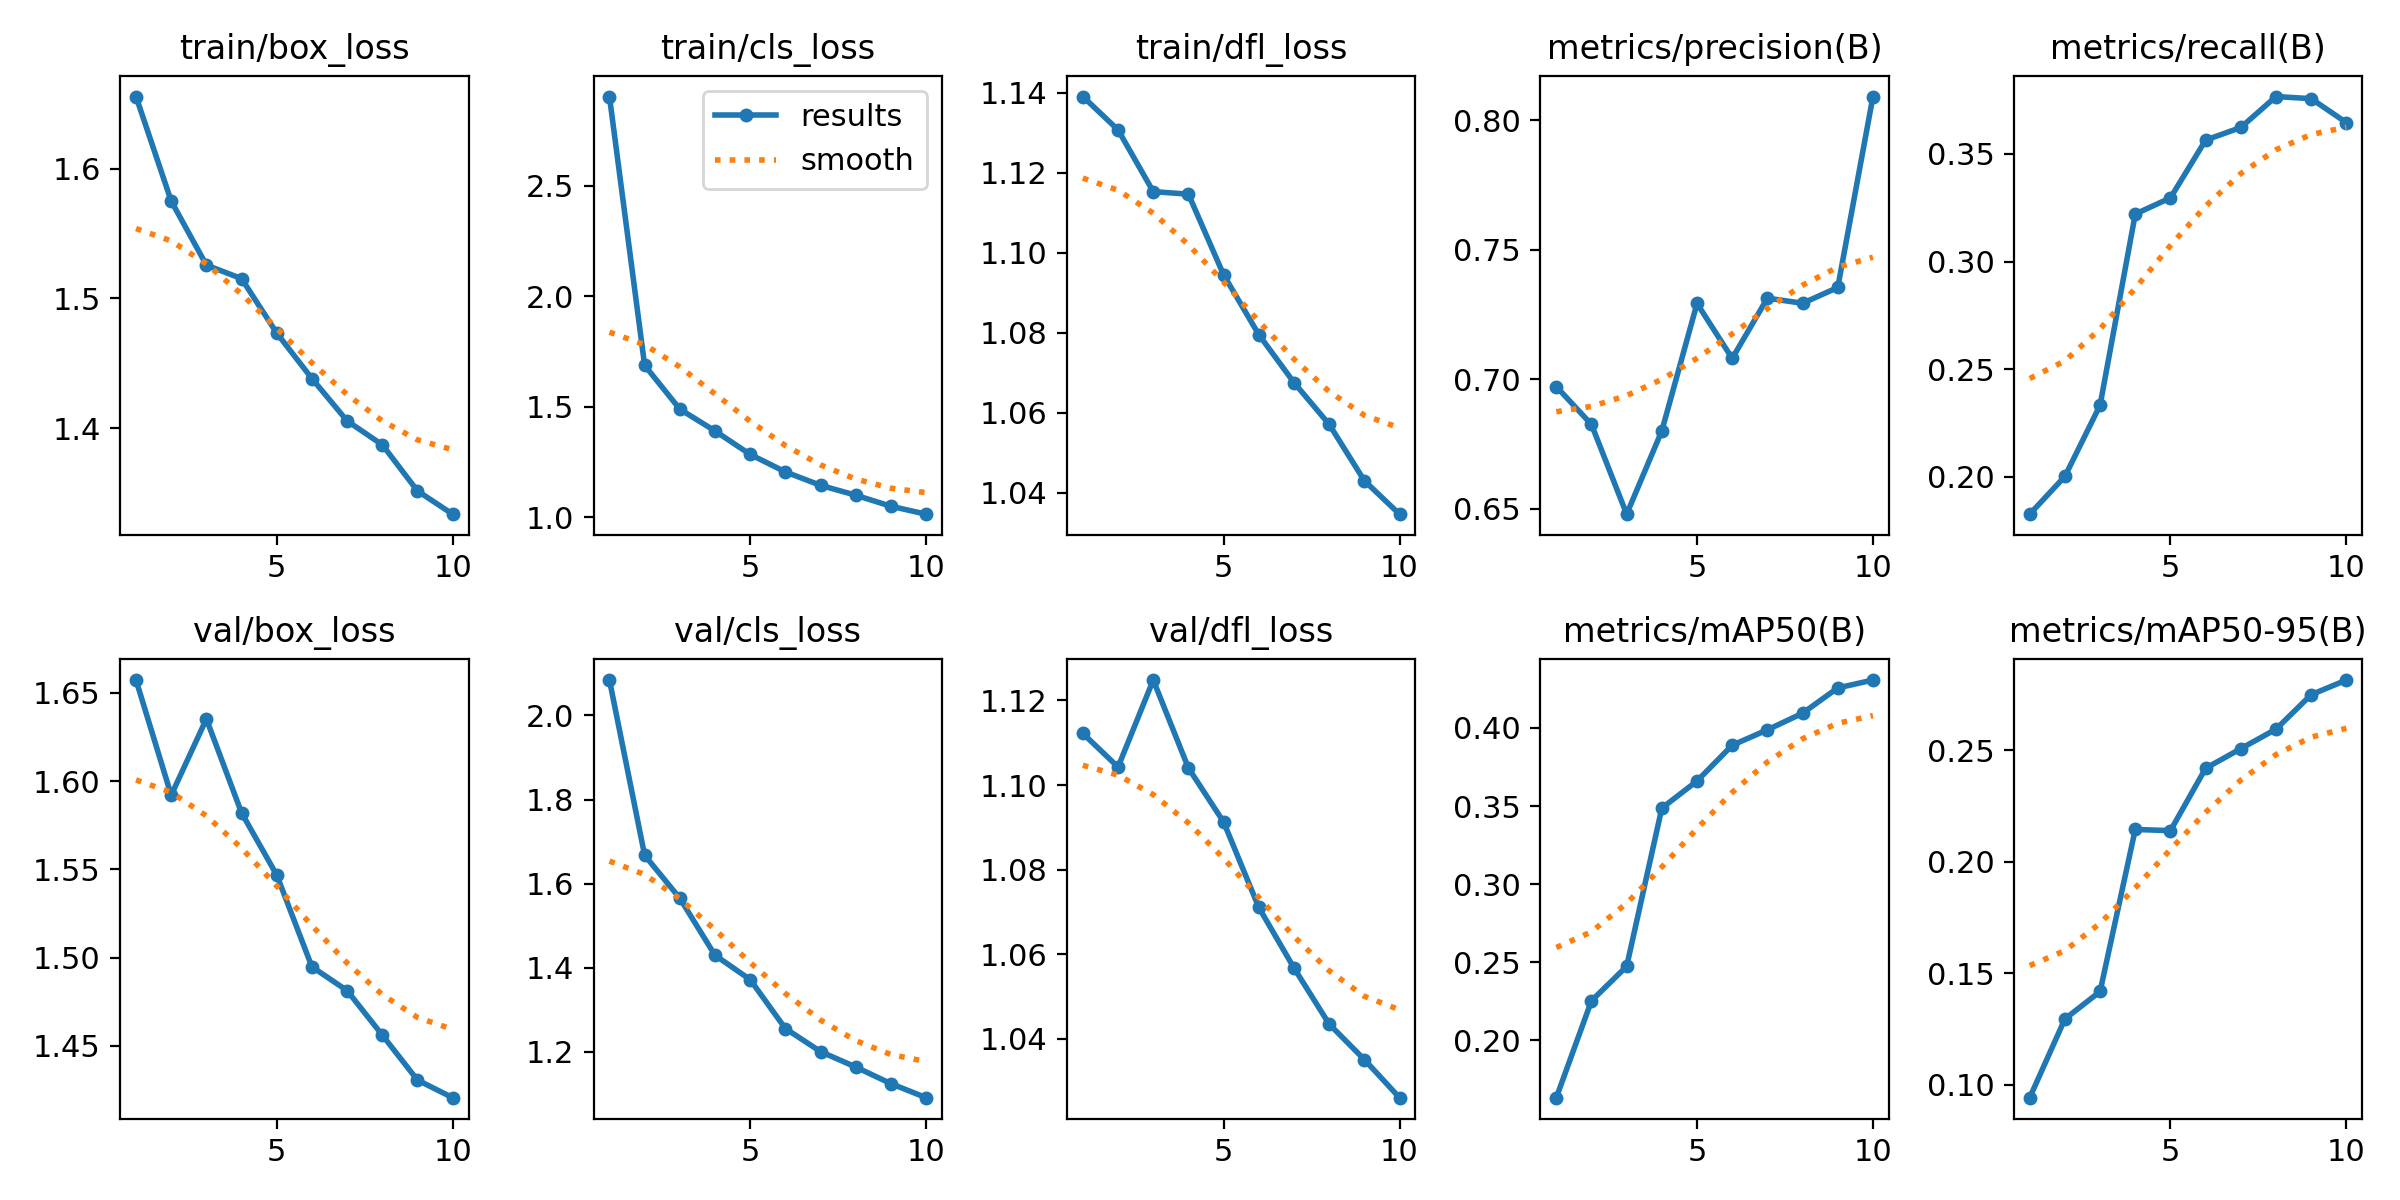

Not found: F1_curve.png
Not found: PR_curve.png
Not found: P_curve.png
Not found: R_curve.png

Showing: confusion_matrix.png


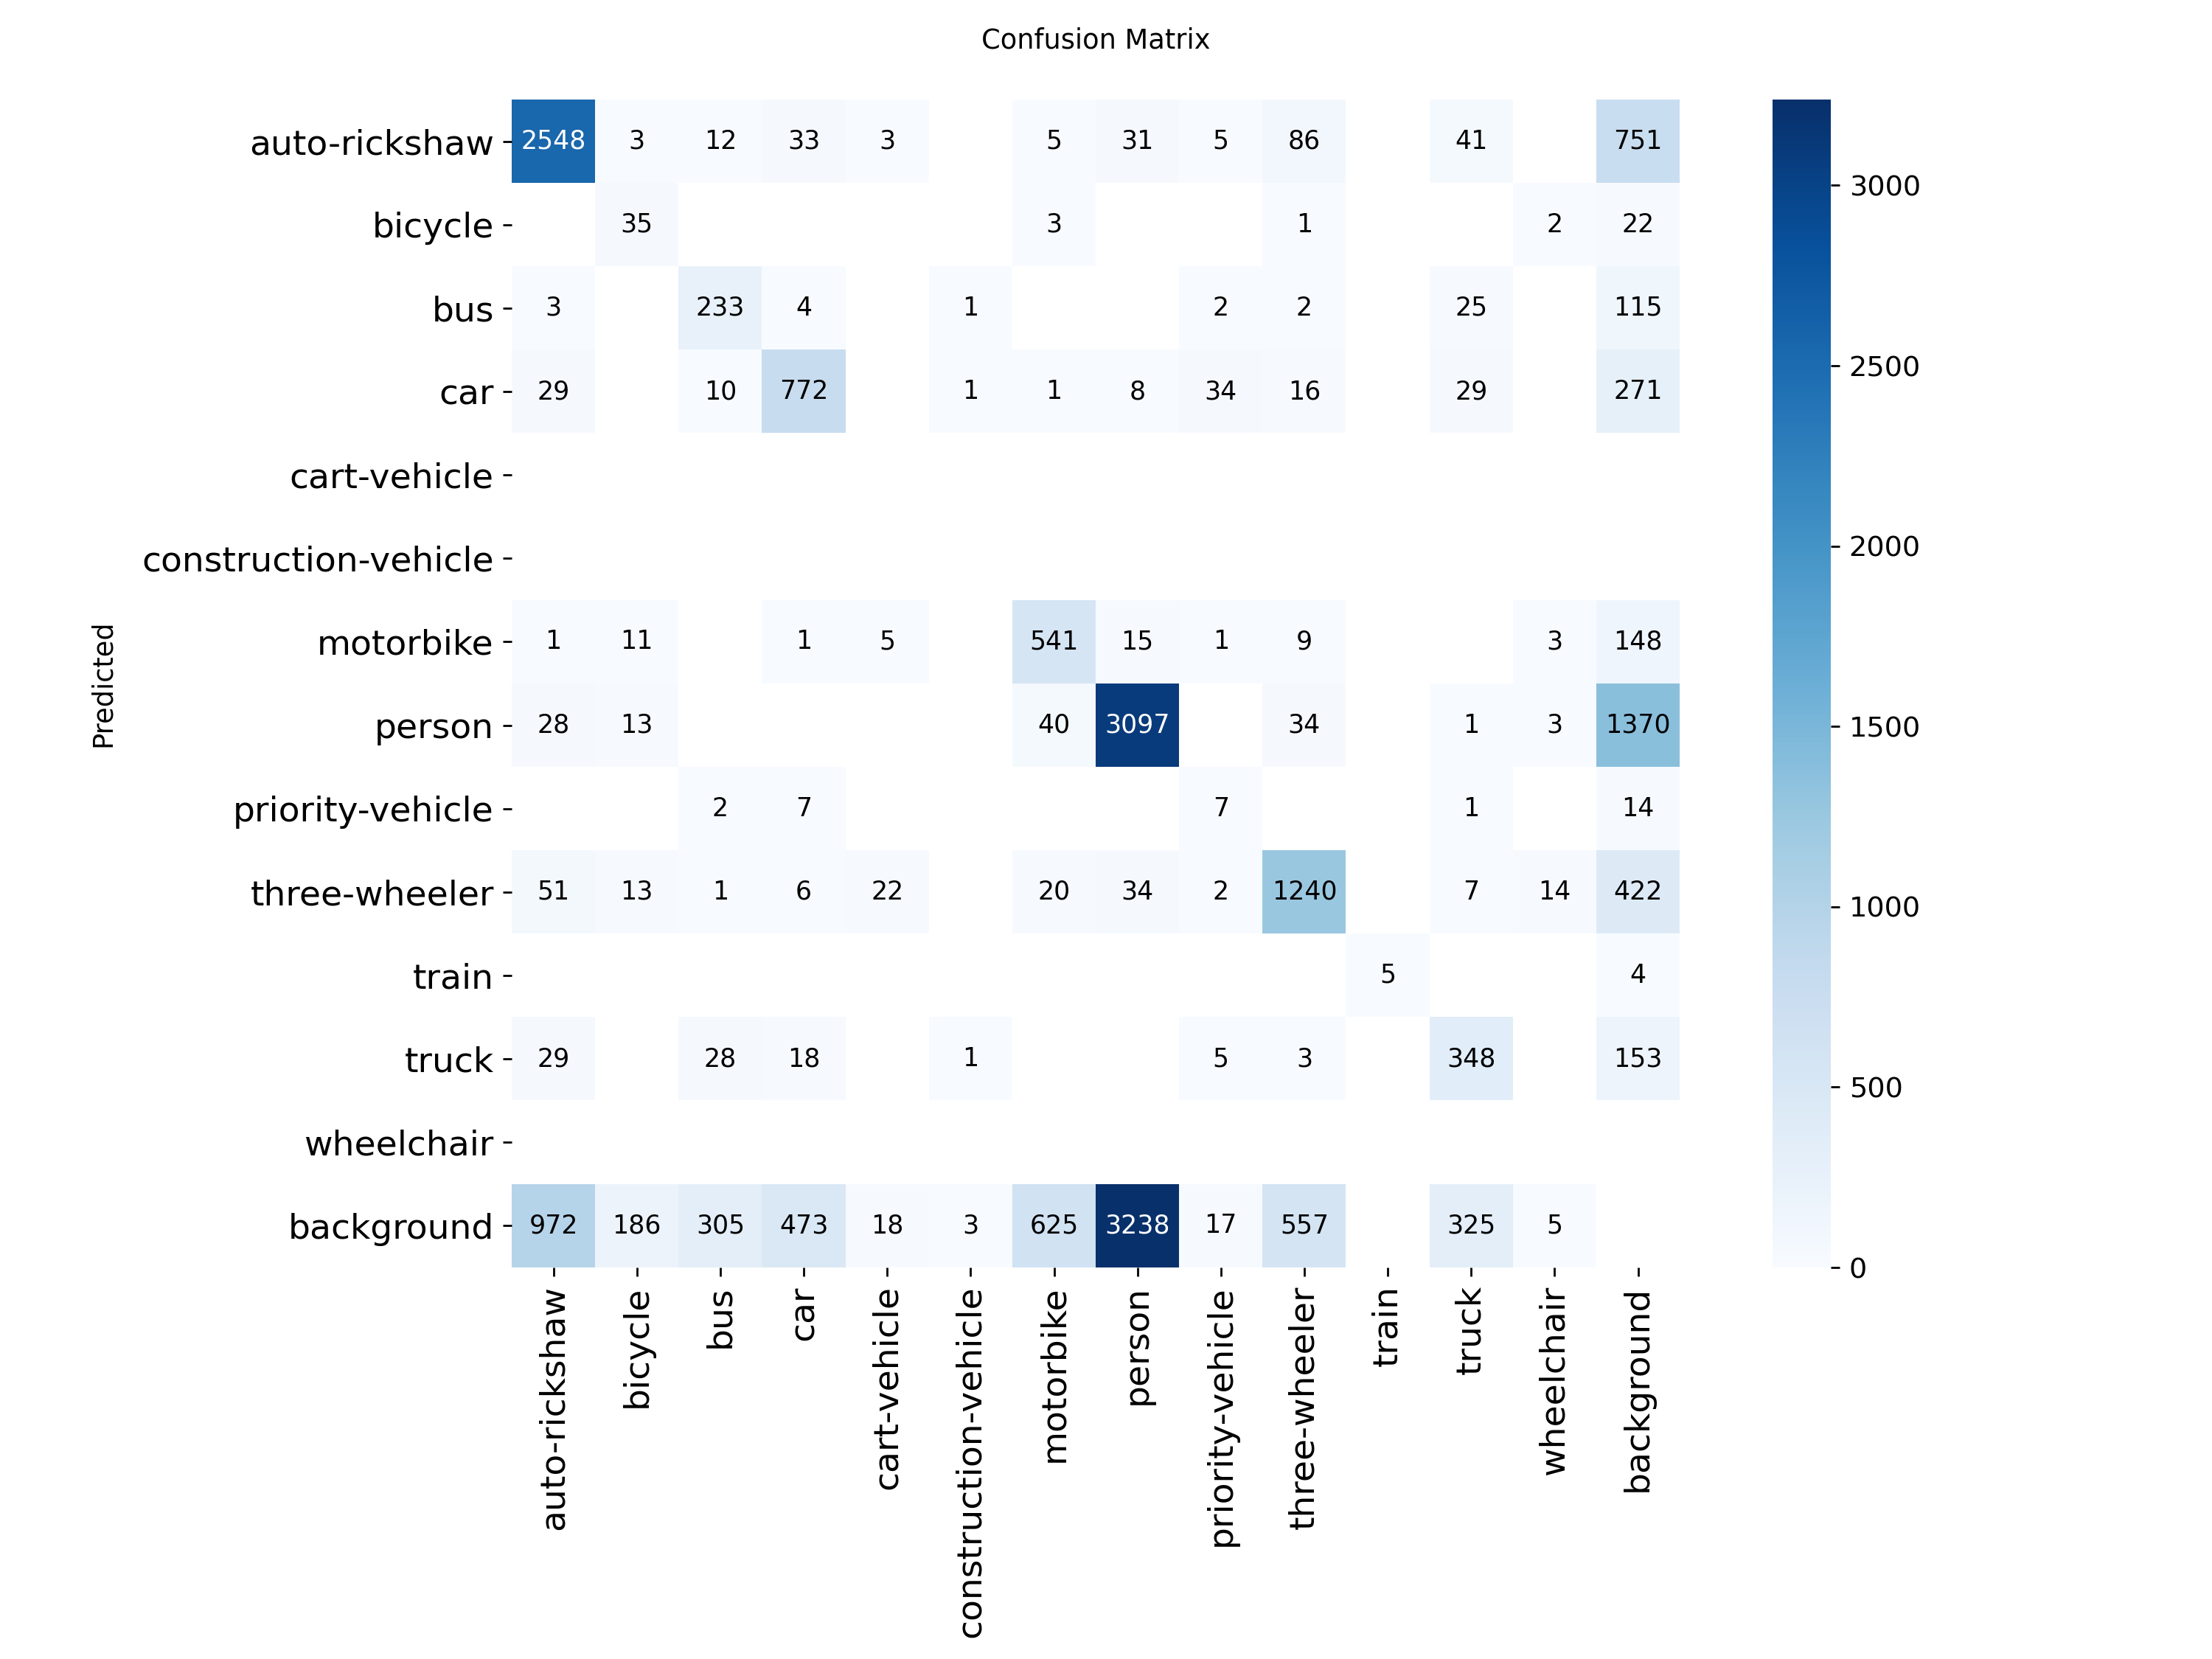

In [30]:
from IPython.display import display, Image as IPyImage
from pathlib import Path

RUN = Path("/kaggle/working/runs/badodd_final")

print("Run folder exists:", RUN.exists())
print("Files found:")
for p in RUN.iterdir():
    print(" -", p.name)

for filename in [
    "results.png",
    "F1_curve.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "confusion_matrix.png"
]:
    p = RUN / filename

    if p.exists():
        print("\nShowing:", filename)
        display(IPyImage(filename=str(p), width=900))
    else:
        print("Not found:", filename)

## 15) Predict sample validation images

In [31]:
from pathlib import Path
from ultralytics import YOLO
import random

# -----------------------------
# Load trained best model
# -----------------------------
BEST = Path(
    "/kaggle/working/runs/badodd_final/weights/best.pt"
)

print("best.pt exists:", BEST.exists())
assert BEST.exists(), "best.pt not found!"

best_model = YOLO(str(BEST))

# -----------------------------
# Find validation images
# -----------------------------
VAL_DIR = Path("/kaggle/input/datasets/val/images")

# fallback if Kaggle mounted under another folder name
if not VAL_DIR.exists():
    candidates = list(Path("/kaggle/input").rglob("val/images"))
    
    if candidates:
        VAL_DIR = candidates[0]
    else:
        raise FileNotFoundError("Validation images folder not found!")

print("Validation folder:", VAL_DIR)

val_imgs = list(VAL_DIR.glob("*.jpg"))

print("Validation images:", len(val_imgs))

# -----------------------------
# Pick 6 random samples
# -----------------------------
sample_sources = [
    str(x)
    for x in random.Random(42).sample(
        val_imgs,
        min(6, len(val_imgs))
    )
]

# -----------------------------
# Prediction
# -----------------------------
pred = best_model.predict(
    source=sample_sources,
    imgsz=416,
    conf=0.25,
    device=0,
    save=True,
    project="/kaggle/working/predictions",
    name="task3_samples",
    exist_ok=True
)

print("\nPrediction completed!")
print(
    "Saved to:",
    "/kaggle/working/predictions/task3_samples"
)

best.pt exists: True
Validation folder: /kaggle/input/datasets/masrafi2221949042/badodd-official/val/images
Validation images: 2032

0: 416x416 1 auto-rickshaw, 1 car, 1 motorbike, 10 persons, 2 three-wheelers, 2.7ms
1: 416x416 3 buss, 2 cars, 3 persons, 1 three-wheeler, 1 truck, 2.7ms
2: 416x416 2 auto-rickshaws, 1 car, 2 motorbikes, 3 persons, 1 three-wheeler, 2.7ms
3: 416x416 2 auto-rickshaws, 1 car, 1 motorbike, 1 person, 2.7ms
4: 416x416 4 auto-rickshaws, 1 car, 1 motorbike, 5 persons, 1 priority-vehicle, 2 three-wheelers, 2.7ms
5: 416x416 6 auto-rickshaws, 4 persons, 2.7ms
Speed: 1.2ms preprocess, 2.7ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /kaggle/working/predictions/task3_samples

Prediction completed!
Saved to: /kaggle/working/predictions/task3_samples


## 16) Display prediction samples

DAY images: 5
NIGHT images: 5

========== 5 DAY PREDICTIONS ==========


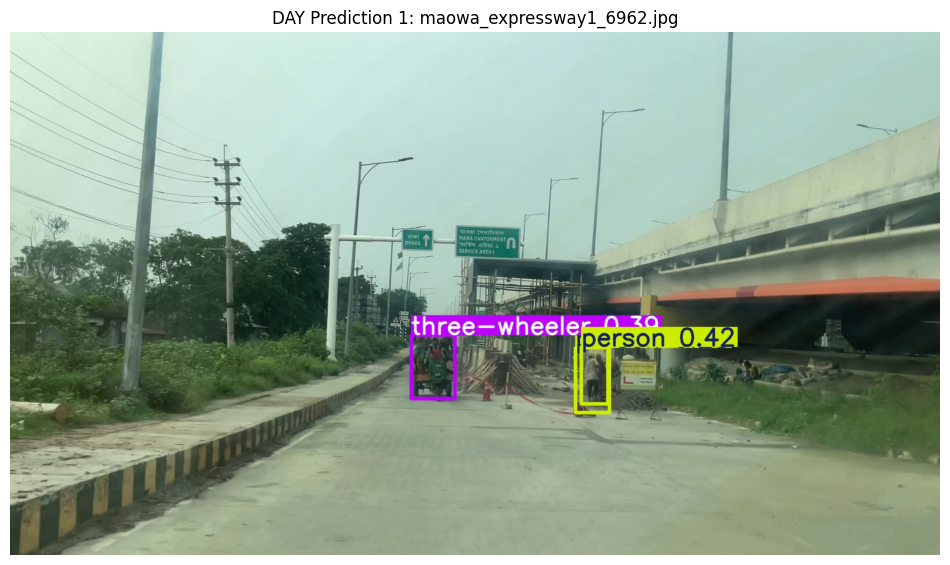

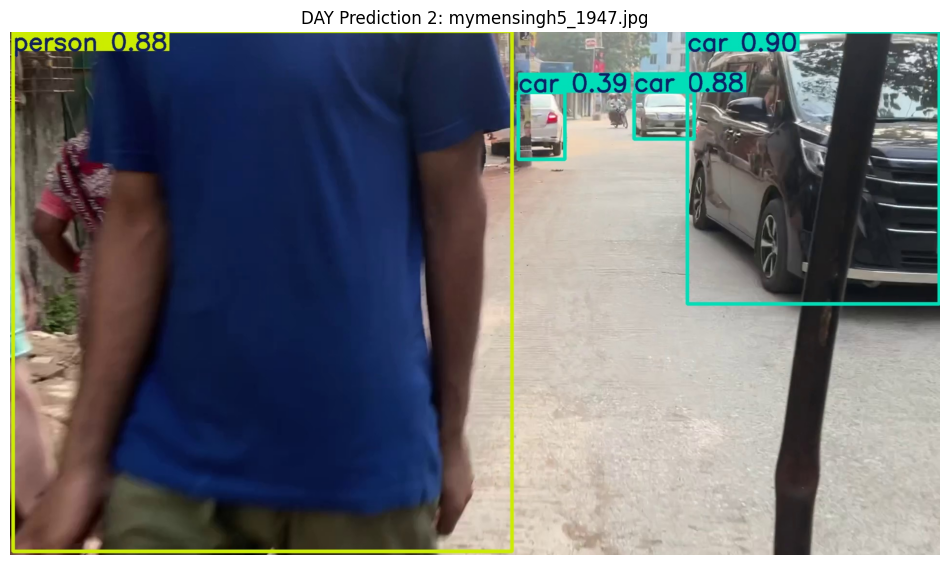

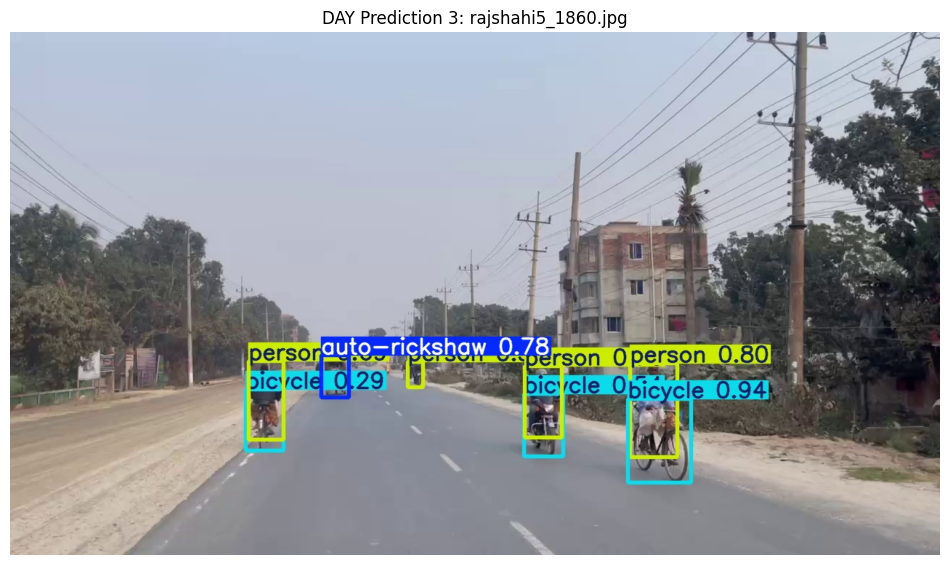

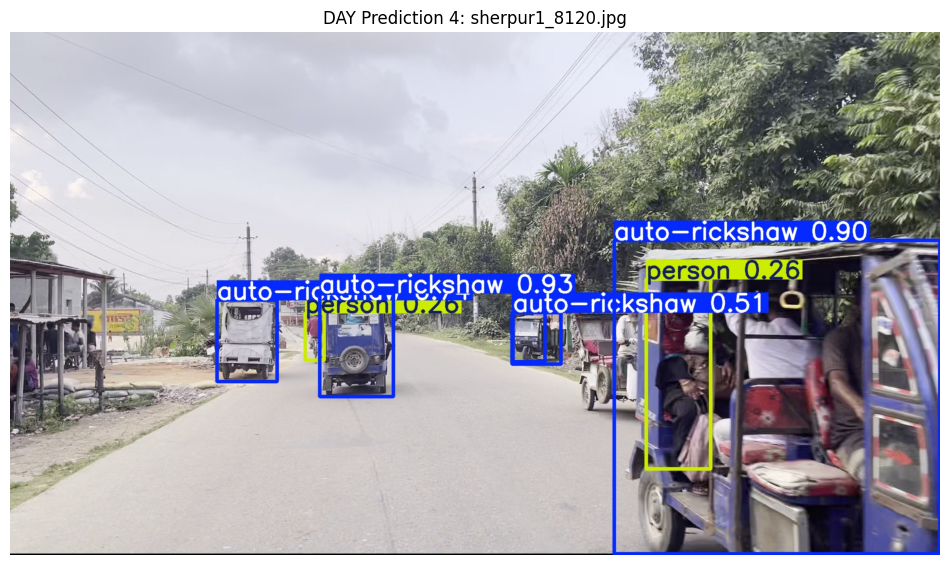

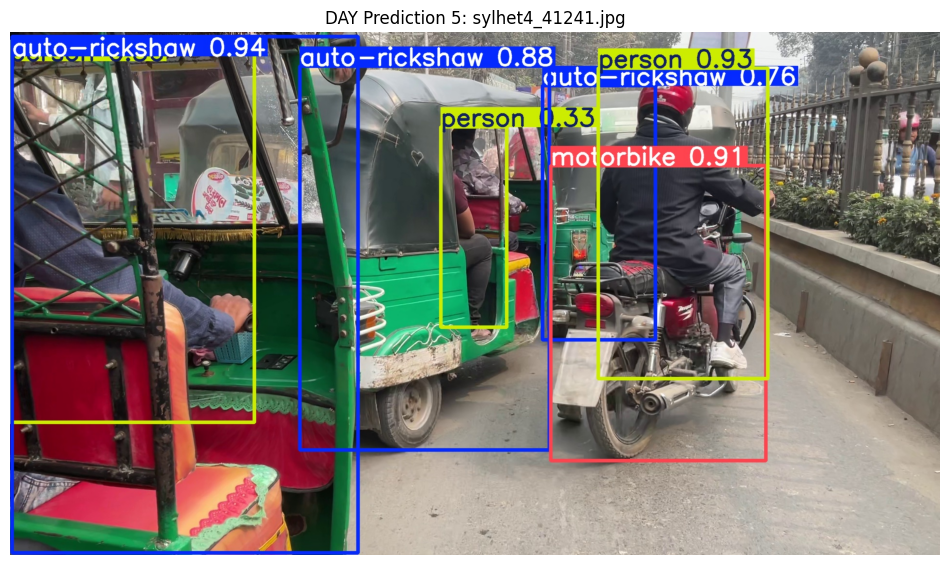


========== 5 NIGHT PREDICTIONS ==========


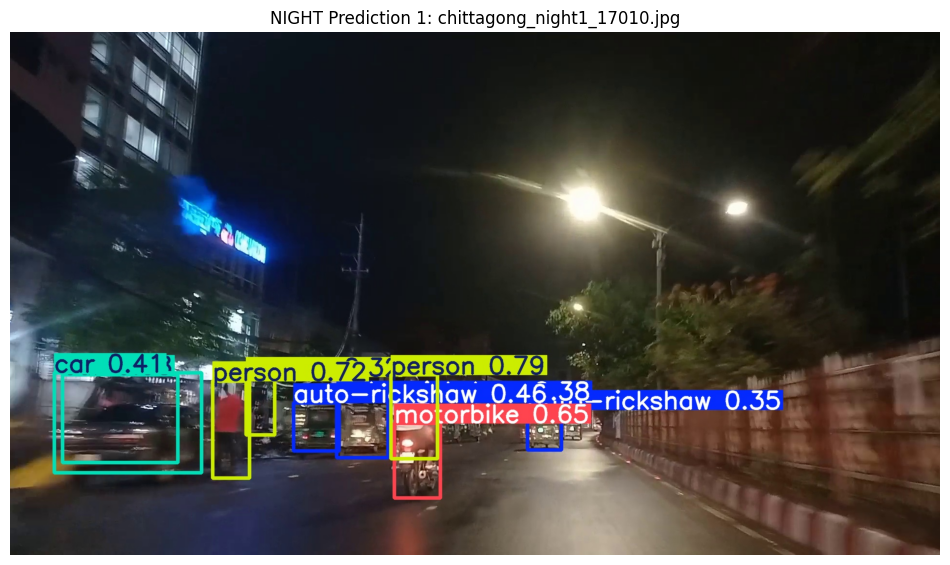

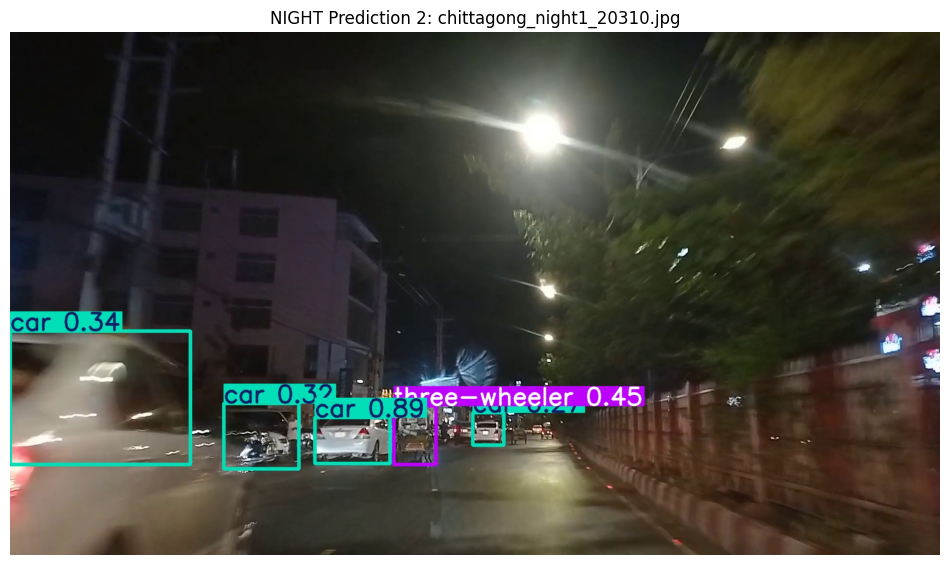

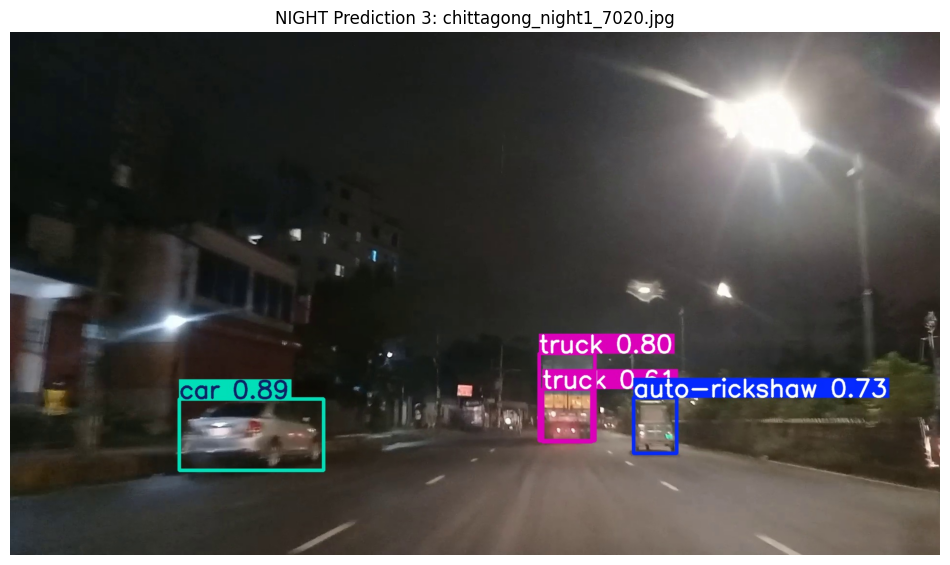

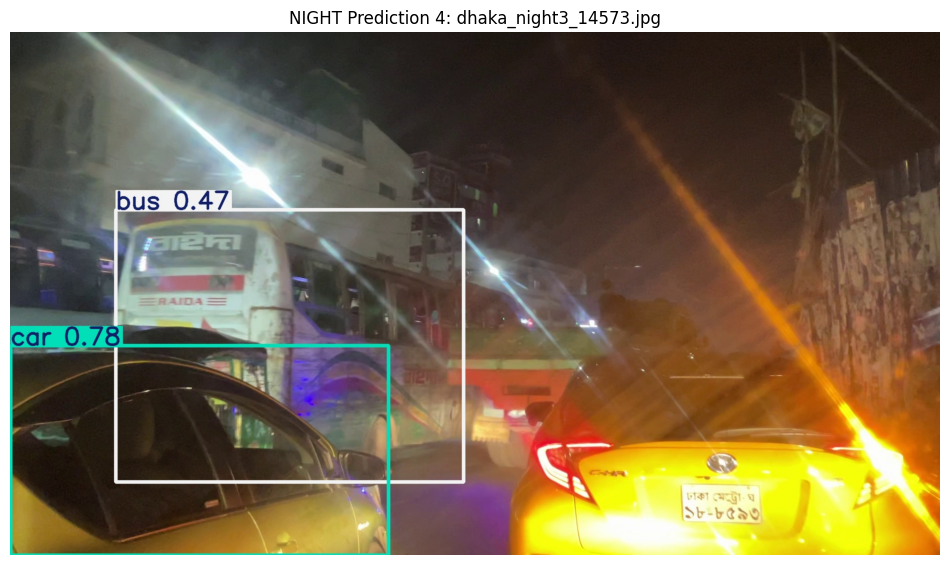

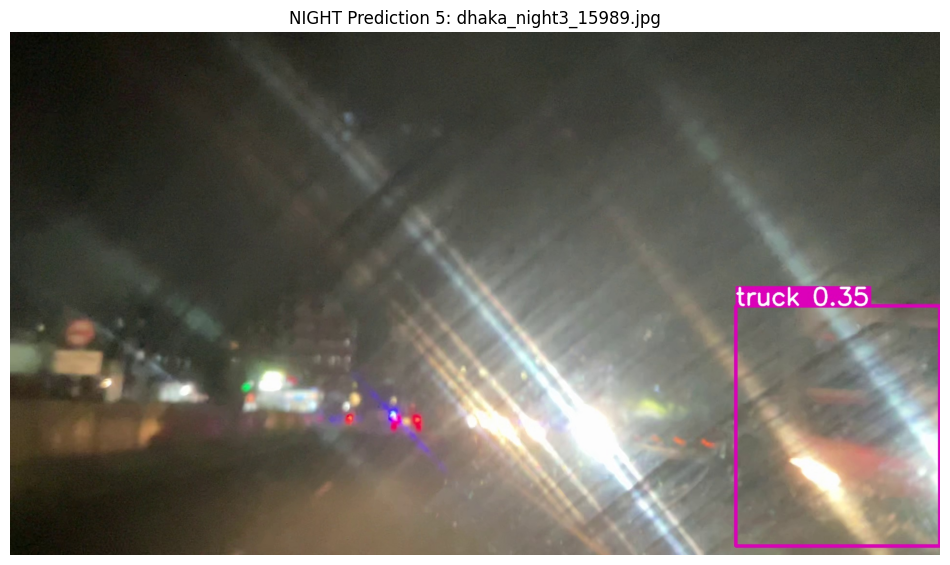

In [34]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DAY_DIR = Path("/kaggle/working/predictions/day_samples")
NIGHT_DIR = Path("/kaggle/working/predictions/night_samples")

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

day_files = sorted([
    p for p in DAY_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in image_exts
])

night_files = sorted([
    p for p in NIGHT_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in image_exts
])

print("DAY images:", len(day_files))
print("NIGHT images:", len(night_files))

print("\n========== 5 DAY PREDICTIONS ==========")

for i, p in enumerate(day_files[:5], 1):
    img = Image.open(p)

    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"DAY Prediction {i}: {p.name}")
    plt.show()

print("\n========== 5 NIGHT PREDICTIONS ==========")

for i, p in enumerate(night_files[:5], 1):
    img = Image.open(p)

    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"NIGHT Prediction {i}: {p.name}")
    plt.show()